In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [25]:
df = pd.read_excel(r"C:\Users\Ravula preethi\Downloads\E-commerce_dataset1.xlsx")

In [26]:
df.head()

,Row_ID,Order _ID,Order_Date,Customer_ID,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
0,1,MX-2015-SC2057582-42279,2023-02-10 00:00:00,SC-2057582,Consumer,Mexico City,Distrito Federal,Mexico,23.634501,-102.552784,Central America,LATAM,hand creams,Body care,L'Oréal Paris Preference - Light Warm Brown,3,48,0.0,19.2
1,2,MX-2013-KW1657028-41562,15-10-2021,KW-1657028,Consumer,Dos Quebradas,Risaralda,Colombia,4.570868,-74.297333,South America,LATAM,hair colors and toners,Hair care,MAC 210 Precise Eye Liner Brush,8,48,0.0,7.2
2,3,MX-2013-KW1657028-41562,15-10-2021,KW-1657028,Consumer,Dos Quebradas,Risaralda,Colombia,4.570868,-74.297333,South America,LATAM,foundations and concealers,Make up,Butter London Nail Lacquer Shag Metallic Copper,2,16,0.0,8.0
3,4,MX-2013-KW1657028-41562,15-10-2021,KW-1657028,Consumer,Dos Quebradas,Risaralda,Colombia,4.570868,-74.297333,South America,LATAM,Nail care products,Body care,Too Faced Natural Eyes Palette Cashmere Bunny,4,28,0.0,14.0
4,5,MX-2013-KW1657028-41562,15-10-2021,KW-1657028,Consumer,Dos Quebradas,Risaralda,Colombia,4.570868,-74.297333,South America,LATAM,Eye shadows and pencils,Make up,LAFCO Lime Basil & Mandarin Diffuser,2,20,0.0,10.0


In [27]:
df.sample()

,Row_ID,Order _ID,Order_Date,Customer_ID,Segment,City,State,Country,Country latitude,Country longitude,Region,Market,Subcategory,Category,Product,Quantity,Sales,Discount,Profit
35760,35761,US-2015-DS13030140-42276,29-09-2023,DS-130301404,Self-Employed,Aurora,Colorado,United States,37.09024,-95.712891,Western US,USCA,Lipsticks,Make up,L'Oréal Paris Feria - Ruby Red,1,20,0.2,4.0


In [28]:
df.columns = df.columns.str.strip().str.replace(' ', '_')

df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

df['Sales'] = df['Sales'].astype(float)

In [29]:
df.isnull().sum()

Row_ID               0
Order__ID            0
Order_Date           0
Customer_ID          0
Segment              0
City                 0
State                0
Country              0
Country_latitude     0
Country_longitude    0
Region               0
Market               0
Subcategory          0
Category             0
Product              0
Quantity             0
Sales                0
Discount             0
Profit               0
dtype: int64

In [30]:
df.shape

(51290, 19)

In [31]:
df.columns


Index(['Row_ID', 'Order__ID', 'Order_Date', 'Customer_ID', 'Segment', 'City',
       'State', 'Country', 'Country_latitude', 'Country_longitude', 'Region',
       'Market', 'Subcategory', 'Category', 'Product', 'Quantity', 'Sales',
       'Discount', 'Profit'],
      dtype='object')

In [32]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row_ID             51290 non-null  int64         
 1   Order__ID          51290 non-null  object        
 2   Order_Date         51290 non-null  datetime64[ns]
 3   Customer_ID        51290 non-null  object        
 4   Segment            51290 non-null  object        
 5   City               51290 non-null  object        
 6   State              51290 non-null  object        
 7   Country            51290 non-null  object        
 8   Country_latitude   51290 non-null  float64       
 9   Country_longitude  51290 non-null  float64       
 10  Region             51290 non-null  object        
 11  Market             51290 non-null  object        
 12  Subcategory        51290 non-null  object        
 13  Category           51290 non-null  object        
 14  Produc

In [33]:
df.describe()

,Row_ID,Order_Date,Country_latitude,Country_longitude,Quantity,Sales,Discount,Profit
count,51290.00000,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2022-05-01 00:22:31.000194816,24.506298,-4.585665,5.415832,127.074946,0.142883,20.772346
min,1.00000,2020-01-01 00:00:00,-40.900557,-106.346771,1.000000,2.000000,0.000000,-1746.000000
25%,12823.25000,2021-06-06 00:00:00,12.879721,-95.712891,2.000000,25.000000,0.000000,0.000000
50%,25645.50000,2022-06-26 00:00:00,35.861660,2.213749,4.000000,56.000000,0.000000,7.200000
75%,38467.75000,2023-04-30 00:00:00,38.963745,43.679291,7.000000,132.000000,0.200000,25.000000
max,51290.00000,2023-12-31 00:00:00,61.924110,174.885971,20.000000,3940.000000,0.850000,1820.000000
std,14806.29199,NaN,24.119393,80.298692,4.908234,236.074764,0.212285,83.582680


#correlation 

In [34]:
df.groupby('Discount')['Profit'].mean().reset_index().sort_values('Discount')

,Discount,Profit
0,0.00,38.748475
1,0.07,23.281800
2,0.10,27.030113
3,0.15,15.114140
4,0.17,17.324381
5,0.20,15.343669
6,0.25,6.875505
7,0.27,14.538505
8,0.30,1.522059
9,0.32,12.267407


In [35]:
df['profit_margin'] = df['Profit'] / df['Sales']
df[['Discount','profit_margin']].corr()

,Discount,profit_margin
Discount,1.000000,-0.766145
profit_margin,-0.766145,1.000000


In [36]:
df[['Discount','Profit']].corr()

,Discount,Profit
Discount,1.00000,-0.31651
Profit,-0.31651,1.00000


In [37]:
df.groupby('Category')[['Discount','profit_margin']].corr()

Discount  profit_margin
Category                                                   
Body care            Discount       1.000000      -0.804065
                     profit_margin -0.804065       1.000000
Face care            Discount       1.000000      -0.967156
                     profit_margin -0.967156       1.000000
Hair care            Discount       1.000000      -1.000000
                     profit_margin -1.000000       1.000000
Home and Accessories Discount       1.000000      -0.999997
                     profit_margin -0.999997       1.000000
Make up              Discount       1.000000      -0.975710
                     profit_margin -0.975710       1.000000

Threshold

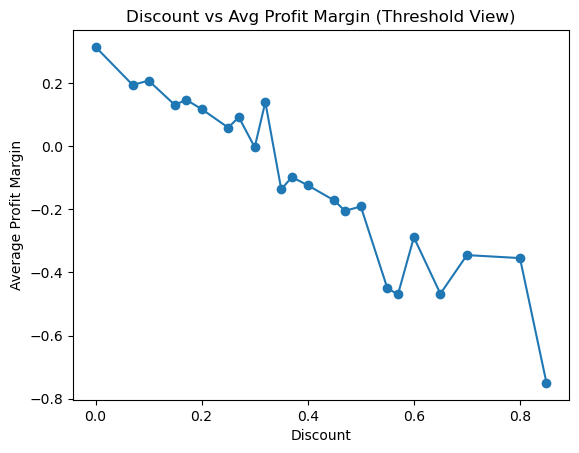

In [39]:
df.groupby('Discount')['profit_margin'].mean().plot(marker='o')
plt.xlabel('Discount')
plt.ylabel('Average Profit Margin')
plt.title('Discount vs Avg Profit Margin (Threshold View)')
plt.show()

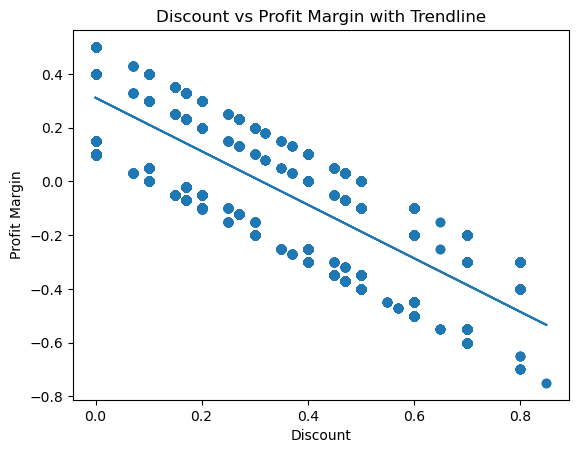

In [40]:


x = df['Discount']
y = df['profit_margin']

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.scatter(x, y)
plt.plot(x, p(x))
plt.xlabel('Discount')
plt.ylabel('Profit Margin')
plt.title('Discount vs Profit Margin with Trendline')
plt.show()

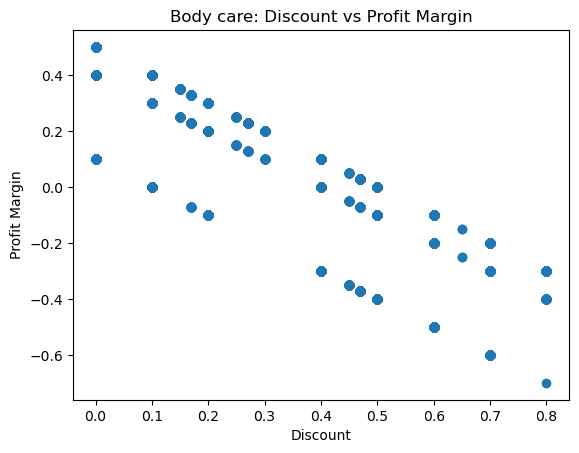

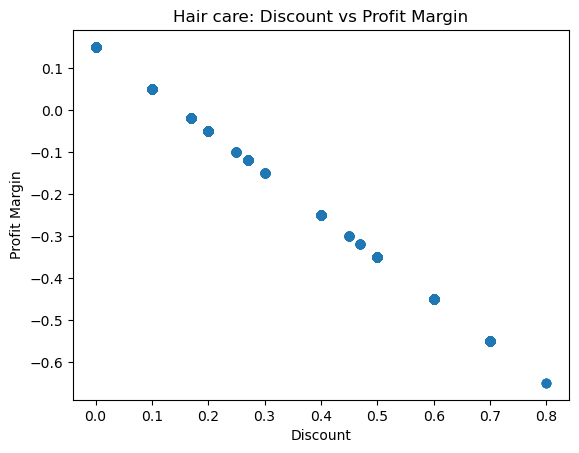

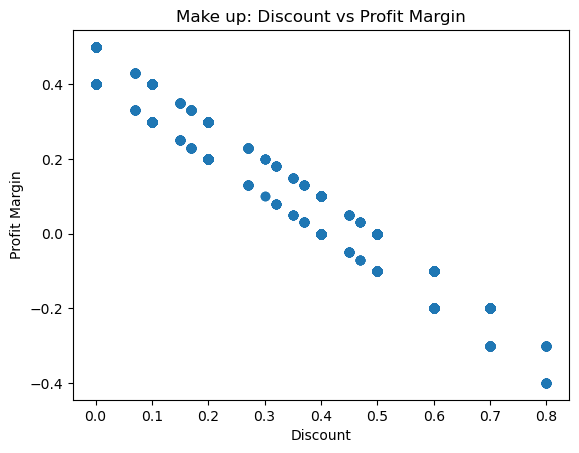

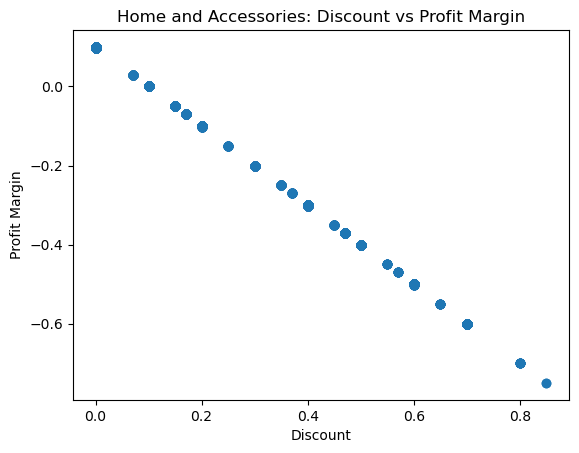

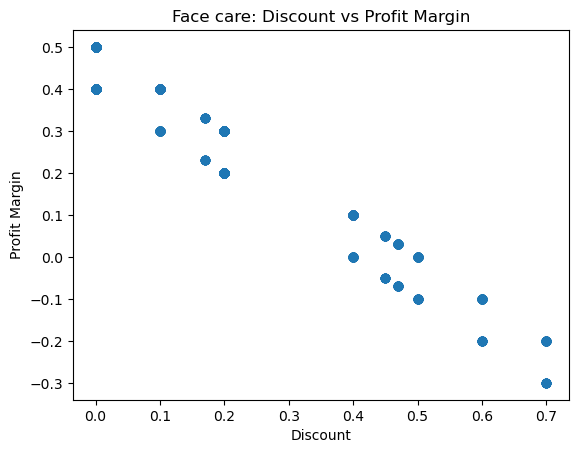

In [41]:
categories = df['Category'].unique()

for cat in categories:
    subset = df[df['Category'] == cat]
    
    plt.scatter(subset['Discount'], subset['profit_margin'])
    plt.title(f'{cat}: Discount vs Profit Margin')
    plt.xlabel('Discount')
    plt.ylabel('Profit Margin')
    plt.show()

In [42]:
def discount_bucket(x):
    if x <= 0.10:
        return '0–10% (Low)'
    elif x <= 0.20:
        return '10–20% (Safe)'
    elif x <= 0.30:
        return '20–30% (Risk)'
    elif x <= 0.40:
        return '30–40% (High Risk)'
    else:
        return '>40% (Loss Zone)'

df['discount_bucket'] = df['Discount'].apply(discount_bucket)

In [46]:

discount_bucket_analysis = (
    df.groupby('discount_bucket')['profit_margin']
    .agg(['mean', 'count'])
    .reset_index()
)

discount_bucket_analysis.columns = [
    'discount_bucket',
    'profit_margin_pct',
    'total_orders'
]


<Axes: xlabel='discount_bucket'>

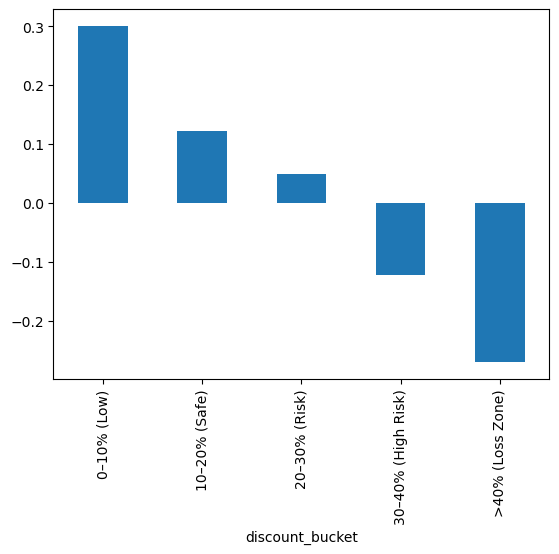

In [47]:
df.groupby('discount_bucket')['profit_margin'].mean().plot(kind='bar')

In [56]:
category_analysis = (
    df.groupby('Category')
    .agg(
        total_profit=('Profit', 'sum')
    )
    .reset_index()
)

category_analysis.columns = [
    'category',
    'total_profit'
]

In [57]:
df.groupby(['Category','discount_bucket'])['profit_margin'].mean()

Category              discount_bucket   
Body care             0–10% (Low)           0.360364
                      10–20% (Safe)         0.221483
                      20–30% (Risk)         0.190673
                      30–40% (High Risk)   -0.036043
                      >40% (Loss Zone)     -0.221607
Face care             0–10% (Low)           0.459503
                      10–20% (Safe)         0.265601
                      30–40% (High Risk)    0.068153
                      >40% (Loss Zone)     -0.070989
Hair care             0–10% (Low)           0.131011
                      10–20% (Safe)        -0.044692
                      20–30% (Risk)        -0.122208
                      30–40% (High Risk)   -0.250000
                      >40% (Loss Zone)     -0.438627
Home and Accessories  0–10% (Low)           0.089395
                      10–20% (Safe)        -0.088552
                      20–30% (Risk)        -0.187179
                      30–40% (High Risk)   -0.294165
     

In [58]:
# % of orders in loss zone
(df[df['Discount'] > 0.40].shape[0] / df.shape[0]) * 100

13.369077792942093

In [59]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['month'] = df['Order_Date'].dt.to_period('M')
df['year'] = df['Order_Date'].dt.year

<Axes: xlabel='month'>

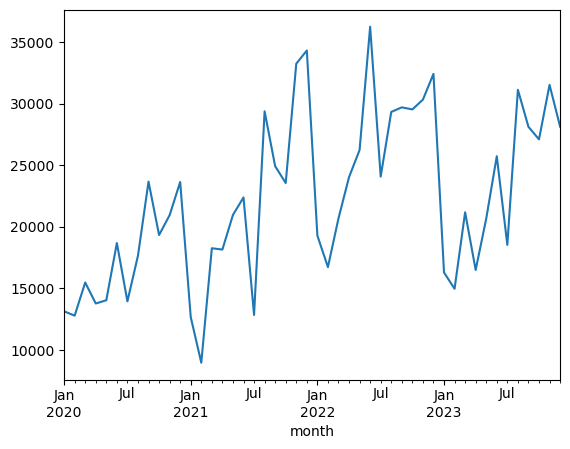

In [60]:
monthly_profit = df.groupby('month')['Profit'].sum()

monthly_profit.plot()

<Axes: xlabel='month'>

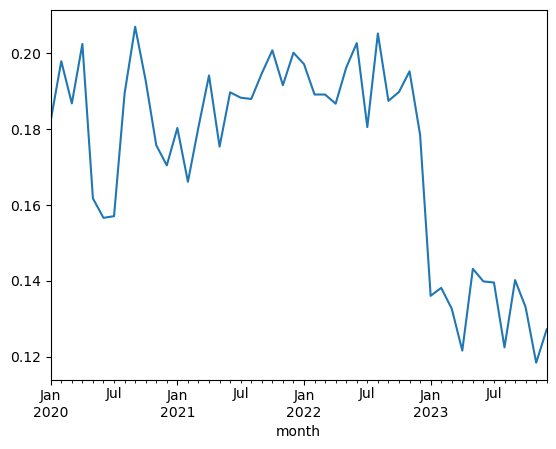

In [61]:
monthly_margin = df.groupby('month')['profit_margin'].mean()

monthly_margin.plot()

<Axes: xlabel='month'>

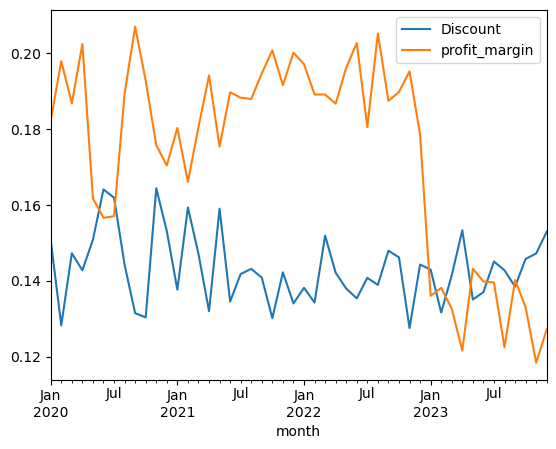

In [62]:
monthly_data = df.groupby('month').agg({
    'Discount':'mean',
    'profit_margin':'mean'
})

monthly_data.plot()

<Axes: xlabel='month'>

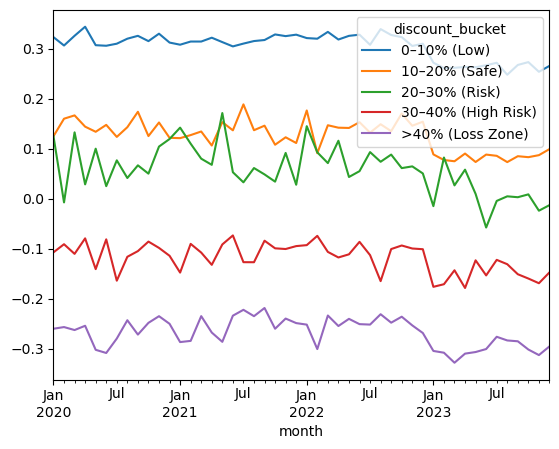

In [63]:
df.groupby(['month','discount_bucket'])['profit_margin'].mean().unstack().plot()

<Axes: xlabel='month'>

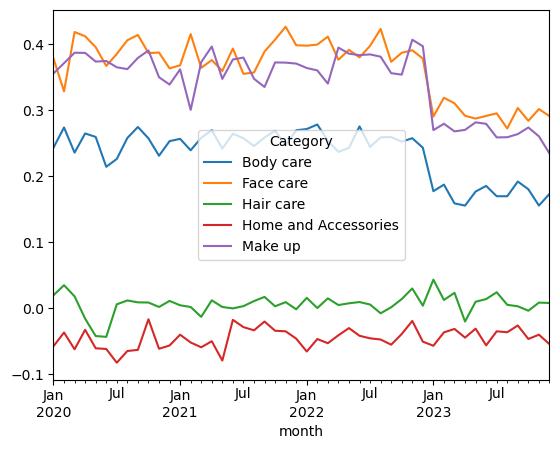

In [64]:
df.groupby(['month','Category'])['profit_margin'].mean().unstack().plot()

In [65]:
print("="*60)
print("STRATEGIC RECOMMENDATIONS")
print("="*60)

# Best discount bucket
best_bucket = discount_bucket_analysis.loc[
    discount_bucket_analysis['profit_margin_pct'].idxmax()
]

# Worst discount bucket
worst_bucket = discount_bucket_analysis.loc[
    discount_bucket_analysis['profit_margin_pct'].idxmin()
]

# Best category
best_category = category_analysis.loc[
    category_analysis['total_profit'].idxmax()
]

# Worst category
worst_category = category_analysis.loc[
    category_analysis['total_profit'].idxmin()
]

print(f"\n BEST PROFITABILITY RANGE:")
print(f" {best_bucket['discount_bucket']} generated the highest profit margin "
      f"of {best_bucket['profit_margin_pct']}%.")

print(f"\n HIGHEST RISK DISCOUNT RANGE:")
print(f" {worst_bucket['discount_bucket']} showed the weakest profitability "
      f"with margin dropping to {worst_bucket['profit_margin_pct']}%.")

print(f"\n BEST PERFORMING CATEGORY:")
print(f" {best_category['category']} generated total profit of "
      f"${best_category['total_profit']:,.2f}.")

print(f"\n MOST LOSS-MAKING CATEGORY:")
print(f" {worst_category['category']} recorded lowest profitability "
      f"with total profit of ${worst_category['total_profit']:,.2f}.")

print("\n RECOMMENDED ACTIONS:")
print("1. Keep discounts below the identified risk threshold.")
print("2. Reduce aggressive discounting in weak-margin categories.")
print("3. Focus promotional campaigns on profitable product groups.")
print("4. Monitor high-discount transactions regularly.")
print("5. Use targeted discounts instead of blanket discounting.")

# Potential recovery opportunity
loss_orders = df[df['Profit'] < 0]

potential_recovery = abs(loss_orders['Profit'].sum())

print("\n POTENTIAL PROFIT RECOVERY:")
print(f" Eliminating loss-making transactions could recover "
      f"${potential_recovery:,.2f} in profit.")

STRATEGIC RECOMMENDATIONS

 BEST PROFITABILITY RANGE:
 0–10% (Low) generated the highest profit margin of 0.3004906198052719%.

 HIGHEST RISK DISCOUNT RANGE:
 >40% (Loss Zone) showed the weakest profitability with margin dropping to -0.27009421029604785%.

 BEST PERFORMING CATEGORY:
 Body care generated total profit of $590,907.78.

 MOST LOSS-MAKING CATEGORY:
 Home and Accessories recorded lowest profitability with total profit of $-57,187.64.

 RECOMMENDED ACTIONS:
1. Keep discounts below the identified risk threshold.
2. Reduce aggressive discounting in weak-margin categories.
3. Focus promotional campaigns on profitable product groups.
4. Monitor high-discount transactions regularly.
5. Use targeted discounts instead of blanket discounting.

 POTENTIAL PROFIT RECOVERY:
 Eliminating loss-making transactions could recover $346,988.23 in profit.
